# DDoS Multimodel Comparison (SetA split + SetB external)

Ez a notebook multiclass `Type` predikciot hasonlit ossze tobb modellen.

Futo scenariok modellenkent:
- Regular tanitas: class_weight hasznalata
- Augmentalt tanitas: SMOTE + class_weight kikapcsolva

Kiértékelés:
- SetA test (in-distribution)
- SetB (external generalization)

Metrikak:
- accuracy
- balanced_accuracy
- f1_macro

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

print("Imports and basic setup done.")

Imports and basic setup done.


In [6]:
# Experiment config

DATA_DIR = Path("ddos-data-2024")

OUT_DIR = Path("ddos-detection/model_comparison")

OUT_DIR.mkdir(parents=True, exist_ok=True)



SETA_NAME = "SCLDDoS2024_SetA"

SETB_NAME = "SCLDDoS2024_SetB"



TARGET_COL = "type"

TEST_SIZE = 0.20

VAL_SIZE = 0.10



MODEL_NAMES = ["logistic_regression", "random_forest", "boosting"]

SCENARIOS = ["regular_class_weight", "smote_no_class_weight"]



# Match the actual CSV schema in this repository.

EVENTS_COLS = [

    "Attack ID", "Card", "Victim IP", "Port number", "Attack code", "Detect count",

    "Packet speed", "Data speed", "Avg packet len", "Avg source IP count",

    "Start time", "End time", "Type",

]



COMP_COLS = [

    "Attack ID", "Detect count", "Card", "Victim IP", "Port number", "Attack code",

    "Packet speed", "Data speed", "Avg packet len", "Source IP count", "Time",

]



print("Data dir:", DATA_DIR.resolve())

print("Output dir:", OUT_DIR.resolve())

Data dir: /home/aron/ml/halado_adatelemzesi_modszerek/ddos-data-2024
Output dir: /home/aron/ml/halado_adatelemzesi_modszerek/ddos-detection/model_comparison


In [3]:
# Optional gradient boosting backend selection
BOOSTING_BACKEND = "histgb"

try:
    from xgboost import XGBClassifier
    BOOSTING_BACKEND = "xgboost"
except Exception:
    try:
        from lightgbm import LGBMClassifier
        BOOSTING_BACKEND = "lightgbm"
    except Exception:
        BOOSTING_BACKEND = "histgb"

print(f"Boosting backend in use: {BOOSTING_BACKEND}")

Boosting backend in use: lightgbm


In [4]:
def _to_snake_case(name: str) -> str:
    name = name.strip().lower()
    name = re.sub(r"[^a-z0-9]+", "_", name)
    return re.sub(r"_+", "_", name).strip("_")


def _safe_mode(series: pd.Series):
    vals = series.mode(dropna=True)
    return vals.iloc[0] if not vals.empty else np.nan


def _log(verbose: bool, msg: str):
    if verbose:
        print(msg)


def preprocess_recordings(recordings, data_dir=DATA_DIR, verbose=True):
    data_dir = Path(data_dir)

    events_frames = []
    comp_frames = []

    for recording in recordings:
        events_path = data_dir / f"{recording}_events.csv"
        comps_path = data_dir / f"{recording}_components.csv"

        if not events_path.exists() or not comps_path.exists():
            raise FileNotFoundError(f"Missing file for recording {recording} under {data_dir}")

        events = pd.read_csv(events_path, usecols=EVENTS_COLS)
        comps = pd.read_csv(comps_path, usecols=COMP_COLS)

        events["recording"] = recording
        comps["recording"] = recording

        events_frames.append(events)
        comp_frames.append(comps)

        _log(verbose, f"[load] {recording}: events={len(events)}, components={len(comps)}")

    events = pd.concat(events_frames, ignore_index=True)
    comps = pd.concat(comp_frames, ignore_index=True)

    _log(verbose, f"[combined] events={len(events)}, components={len(comps)}")

    # Basic dedup and datetime parsing
    events = events.drop_duplicates().copy()
    comps = comps.drop_duplicates().copy()

    events["Start time"] = pd.to_datetime(events["Start time"], errors="coerce")
    events["End time"] = pd.to_datetime(events["End time"], errors="coerce")
    comps["Time"] = pd.to_datetime(comps["Time"], errors="coerce")

    events = events.dropna(subset=["Attack ID", "Type", "Start time", "End time"]).copy()
    comps = comps.dropna(subset=["Attack ID", "Time"]).copy()

    events = events.loc[events["End time"] >= events["Start time"]].copy()

    valid_ids = set(events["Attack ID"].unique())
    comps = comps.loc[comps["Attack ID"].isin(valid_ids)].copy()

    # Event-level features (include features from both previous notebooks)
    events["event_duration_sec"] = (events["End time"] - events["Start time"]).dt.total_seconds()
    events["day_of_week"] = events["Start time"].dt.dayofweek
    events["hour_of_day"] = events["Start time"].dt.hour
    events["is_weekend"] = (events["day_of_week"] >= 5).astype(int)

    events["packet_data_ratio"] = events["Packet speed"] / (events["Data speed"].replace(0, np.nan))
    events["packet_data_ratio"] = events["packet_data_ratio"].replace([np.inf, -np.inf], np.nan)
    events["attack_intensity"] = events["Packet speed"] * events["Avg source IP count"]

    # Component-level aggregates
    comp_agg = (
        comps.groupby("Attack ID", as_index=False)
        .agg(
            comp_row_count=("Detect count", "size"),
            comp_detect_count_max=("Detect count", "max"),
            comp_packet_speed_mean=("Packet speed", "mean"),
            comp_packet_speed_max=("Packet speed", "max"),
            comp_packet_speed_std=("Packet speed", "std"),
            comp_avg_packet_len_mean=("Avg packet len", "mean"),
            comp_source_ip_count_mean=("Source IP count", "mean"),
            comp_source_ip_count_max=("Source IP count", "max"),
            comp_attack_code_mode=("Attack code", _safe_mode),
            comp_card_mode=("Card", _safe_mode),
            comp_first_time=("Time", "min"),
            comp_last_time=("Time", "max"),
        )
        .copy()
    )

    comp_agg["comp_packet_speed_std"] = comp_agg["comp_packet_speed_std"].fillna(0)
    comp_agg["comp_duration_sec"] = (comp_agg["comp_last_time"] - comp_agg["comp_first_time"]).dt.total_seconds()
    comp_agg["source_ip_growth_rate"] = np.where(
        comp_agg["comp_duration_sec"] > 0,
        comp_agg["comp_source_ip_count_max"] / comp_agg["comp_duration_sec"],
        0.0,
    )

    # Keep one row per Attack ID on event side, then merge
    events = events.sort_values("Start time").drop_duplicates(subset=["Attack ID"], keep="last").copy()
    merged = events.merge(comp_agg, on="Attack ID", how="left")

    # Drop irrelevant fields and redundant raw Data speed
    merged = merged.drop(columns=["Victim IP", "Significant flag", "Whitelist flag", "Data speed"], errors="ignore")

    # Snake case
    merged.columns = [_to_snake_case(c) for c in merged.columns]

    # Fill missing values
    num_cols = merged.select_dtypes(include=["number"]).columns
    obj_cols = merged.select_dtypes(exclude=["number"]).columns
    merged[num_cols] = merged[num_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    merged[obj_cols] = merged[obj_cols].fillna("missing")

    _log(verbose, f"[preprocess] rows={len(merged)}, cols={merged.shape[1]}")
    return merged

In [7]:
seta_all = preprocess_recordings([SETA_NAME], data_dir=DATA_DIR, verbose=True)
setb_all = preprocess_recordings([SETB_NAME], data_dir=DATA_DIR, verbose=True)

def _safe_stratify(y: pd.Series):
    if y.nunique() <= 1:
        return None
    if y.value_counts().min() < 2:
        return None
    return y

strat = _safe_stratify(seta_all[TARGET_COL])
seta_train_val, seta_test = train_test_split(
    seta_all,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=strat,
)

val_ratio_in_train_val = VAL_SIZE / (1.0 - TEST_SIZE)
strat_tv = _safe_stratify(seta_train_val[TARGET_COL])
seta_train, seta_val = train_test_split(
    seta_train_val,
    test_size=val_ratio_in_train_val,
    random_state=RANDOM_STATE,
    stratify=strat_tv,
)

print("SetA splits:")
print("- train:", seta_train.shape)
print("- val:", seta_val.shape)
print("- test:", seta_test.shape)
print("SetB all:", setb_all.shape)

print("\nSetA train class distribution:")
display(seta_train[TARGET_COL].value_counts())

print("SetA test class distribution:")
display(seta_test[TARGET_COL].value_counts())

print("SetB class distribution:")
display(setb_all[TARGET_COL].value_counts())

[load] SCLDDoS2024_SetA: events=134770, components=586642
[combined] events=134770, components=586642
[preprocess] rows=134766, cols=32
[load] SCLDDoS2024_SetB: events=130000, components=1233449
[combined] events=130000, components=1233449
[preprocess] rows=130000, cols=32
SetA splits:
- train: (94335, 32)
- val: (13477, 32)
- test: (26954, 32)
SetB all: (130000, 32)

SetA train class distribution:


type
Normal traffic        86892
Suspicious traffic     6794
DDoS attack             649
Name: count, dtype: int64

SetA test class distribution:


type
Normal traffic        24827
Suspicious traffic     1942
DDoS attack             185
Name: count, dtype: int64

SetB class distribution:


type
Normal traffic        124880
Suspicious traffic      3673
DDoS attack             1447
Name: count, dtype: int64

In [8]:
LEAKAGE_DROP_COLS = [
    TARGET_COL,
    "attack_id",
    "recording",
    "start_time",
    "end_time",
    "comp_first_time",
    "comp_last_time",
    "attack_code",
    "comp_attack_code_mode",
]

def split_xy(df: pd.DataFrame, target_col: str = TARGET_COL):
    usable_drop = [c for c in LEAKAGE_DROP_COLS if c in df.columns]
    X = df.drop(columns=usable_drop).copy()
    y = df[target_col].copy()
    return X, y

X_train_raw, y_train = split_xy(seta_train)
X_val_raw, y_val = split_xy(seta_val)
X_test_raw, y_test = split_xy(seta_test)
X_setb_raw, y_setb = split_xy(setb_all)

cat_cols = X_train_raw.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()
num_cols = X_train_raw.select_dtypes(include=["number"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            num_cols,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            cat_cols,
        ),
    ],
    remainder="drop",
)

X_train_enc = preprocessor.fit_transform(X_train_raw)
X_val_enc = preprocessor.transform(X_val_raw)
X_test_enc = preprocessor.transform(X_test_raw)
X_setb_enc = preprocessor.transform(X_setb_raw)

def to_dense(X):
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)

X_train_enc = to_dense(X_train_enc).astype(np.float32)
X_val_enc = to_dense(X_val_enc).astype(np.float32)
X_test_enc = to_dense(X_test_enc).astype(np.float32)
X_setb_enc = to_dense(X_setb_enc).astype(np.float32)

feature_names = preprocessor.get_feature_names_out().tolist()
print("Encoded feature count:", len(feature_names))

Encoded feature count: 23


In [9]:
def compute_multiclass_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
    }


def balanced_sample_weights(y: pd.Series) -> np.ndarray:
    classes = np.unique(y)
    cw = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    cw_map = dict(zip(classes, cw))
    return y.map(cw_map).values.astype(np.float32)


def make_model(model_name: str, use_class_weight: bool):
    if model_name == "logistic_regression":
        return LogisticRegression(
            max_iter=2000,
            solver="lbfgs",
            class_weight=("balanced" if use_class_weight else None),
            random_state=RANDOM_STATE,
        )

    if model_name == "random_forest":
        return RandomForestClassifier(
            n_estimators=350,
            max_depth=18,
            min_samples_leaf=2,
            class_weight=("balanced_subsample" if use_class_weight else None),
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )

    if model_name == "boosting":
        if BOOSTING_BACKEND == "xgboost":
            return XGBClassifier(
                objective="multi:softprob",
                eval_metric="mlogloss",
                n_estimators=350,
                max_depth=8,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )

        if BOOSTING_BACKEND == "lightgbm":
            return LGBMClassifier(
                objective="multiclass",
                n_estimators=350,
                learning_rate=0.05,
                num_leaves=63,
                subsample=0.9,
                colsample_bytree=0.9,
                class_weight=("balanced" if use_class_weight else None),
                random_state=RANDOM_STATE,
            )

        return HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=350,
            max_depth=10,
            random_state=RANDOM_STATE,
        )

    raise ValueError(f"Unknown model: {model_name}")


def apply_smote_train_only(X_train, y_train):
    class_counts = y_train.value_counts()
    min_count = int(class_counts.min())
    if min_count < 2:
        raise ValueError("SMOTE requires at least 2 samples in the smallest class.")

    k_neighbors = min(5, min_count - 1)
    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors)
    X_res, y_res = smote.fit_resample(X_train, y_train)
    return X_res, y_res


def fit_and_eval(model_name: str, scenario: str):
    if scenario not in SCENARIOS:
        raise ValueError(f"Unknown scenario: {scenario}")

    use_class_weight = scenario == "regular_class_weight"

    if scenario == "smote_no_class_weight":
        X_fit, y_fit = apply_smote_train_only(X_train_enc, y_train)
    else:
        X_fit, y_fit = X_train_enc, y_train

    model = make_model(model_name, use_class_weight=use_class_weight)

    fit_kwargs = {}
    if scenario == "regular_class_weight" and model_name == "boosting" and BOOSTING_BACKEND in {"xgboost", "histgb"}:
        fit_kwargs["sample_weight"] = balanced_sample_weights(y_fit)

    t0 = time.perf_counter()
    model.fit(X_fit, y_fit, **fit_kwargs)
    fit_time = time.perf_counter() - t0

    t1 = time.perf_counter()
    pred_test = model.predict(X_test_enc)
    pred_setb = model.predict(X_setb_enc)
    predict_time = time.perf_counter() - t1

    test_metrics = compute_multiclass_metrics(y_test, pred_test)
    setb_metrics = compute_multiclass_metrics(y_setb, pred_setb)

    rows = [
        {
            "model": model_name,
            "scenario": scenario,
            "dataset": "seta_test",
            **test_metrics,
            "fit_time_sec": fit_time,
            "predict_time_sec": predict_time,
        },
        {
            "model": model_name,
            "scenario": scenario,
            "dataset": "setb_external",
            **setb_metrics,
            "fit_time_sec": fit_time,
            "predict_time_sec": predict_time,
        },
    ]

    pred_store = {
        "seta_test": pred_test,
        "setb_external": pred_setb,
    }
    return model, rows, pred_store

In [10]:
results_rows = []
trained_models = {}
predictions = {}

for model_name in MODEL_NAMES:
    for scenario in SCENARIOS:
        print(f"Running: model={model_name}, scenario={scenario}")
        model, rows, pred_store = fit_and_eval(model_name, scenario)

        trained_models[(model_name, scenario)] = model
        predictions[(model_name, scenario)] = pred_store
        results_rows.extend(rows)

results_df = pd.DataFrame(results_rows)
results_df = results_df.sort_values(["dataset", "f1_macro", "balanced_accuracy"], ascending=[True, False, False]).reset_index(drop=True)

display(results_df)
print("\nRows in results table:", len(results_df))

Running: model=logistic_regression, scenario=regular_class_weight
Running: model=logistic_regression, scenario=smote_no_class_weight
Running: model=random_forest, scenario=regular_class_weight
Running: model=random_forest, scenario=smote_no_class_weight
Running: model=boosting, scenario=regular_class_weight
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002400 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4593
[LightGBM] [Info] Number of data points in the train set: 94335, number of used features: 21
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Running: model=boosting, scenario=smote_no_class_weight
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003393 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Tota

,model,scenario,dataset,accuracy,balanced_accuracy,f1_macro,fit_time_sec,predict_time_sec
0,boosting,smote_no_class_weight,seta_test,0.961675,0.870865,0.847417,3.144922,0.570133
1,boosting,regular_class_weight,seta_test,0.955035,0.888474,0.836456,1.643092,0.622353
2,random_forest,regular_class_weight,seta_test,0.947132,0.875771,0.832741,2.591633,0.258179
3,random_forest,smote_no_class_weight,seta_test,0.943533,0.895723,0.811550,9.451918,0.269625
4,logistic_regression,smote_no_class_weight,seta_test,0.650293,0.698597,0.390699,11.202225,0.018255
5,logistic_regression,regular_class_weight,seta_test,0.653372,0.685706,0.390148,2.030196,0.017958
6,random_forest,regular_class_weight,setb_external,0.938115,0.464864,0.513302,2.591633,0.258179
7,boosting,smote_no_class_weight,setb_external,0.938277,0.487107,0.475855,3.144922,0.570133
8,boosting,regular_class_weight,setb_external,0.926162,0.473574,0.464351,1.643092,0.622353
9,random_forest,smote_no_class_weight,setb_external,0.923992,0.473697,0.438332,9.451918,0.269625



Rows in results table: 12


accuracy               balanced_accuracy                f1_macro              
dataset                                   seta_test setb_external         seta_test setb_external seta_test setb_external
model               scenario                                                                                             
boosting            regular_class_weight   0.955035      0.926162          0.888474      0.473574  0.836456      0.464351
                    smote_no_class_weight  0.961675      0.938277          0.870865      0.487107  0.847417      0.475855
logistic_regression regular_class_weight   0.653372      0.629362          0.685706      0.343574  0.390148      0.282943
                    smote_no_class_weight  0.650293      0.600877          0.698597      0.337877  0.390699      0.272379
random_forest       regular_class_weight   0.947132      0.938115          0.875771      0.464864  0.832741      0.513302
                    smote_no_class_weight  0.943533      0.923992          0.895723      0.473697  0.811550      0.438332

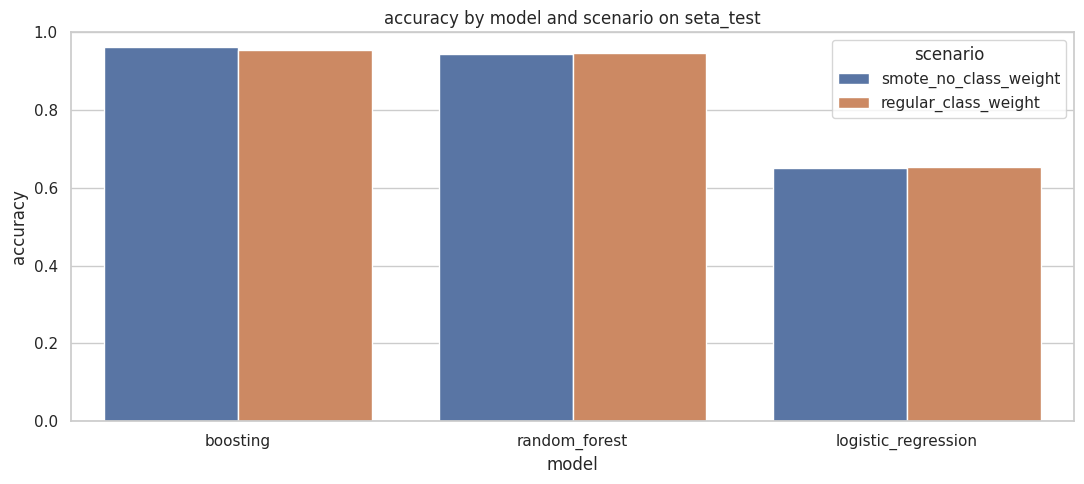

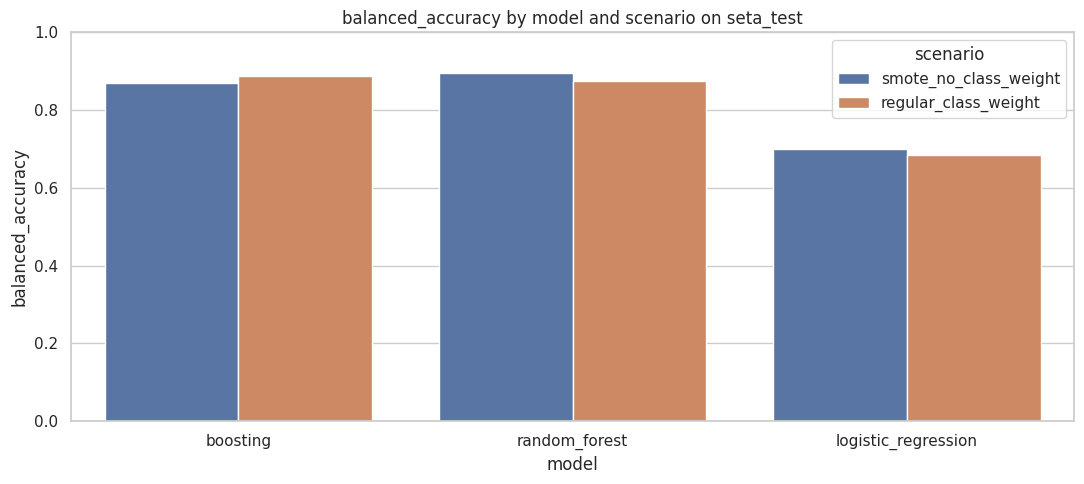

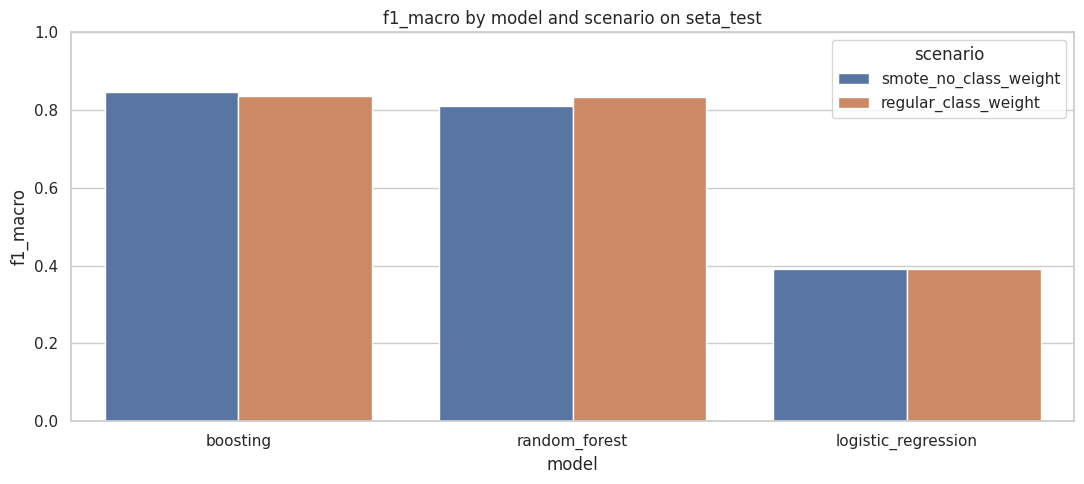

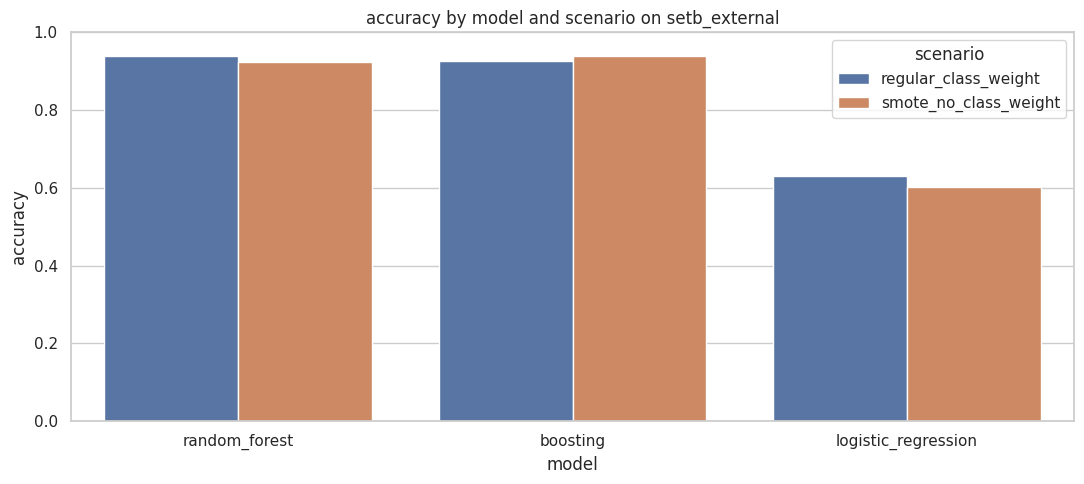

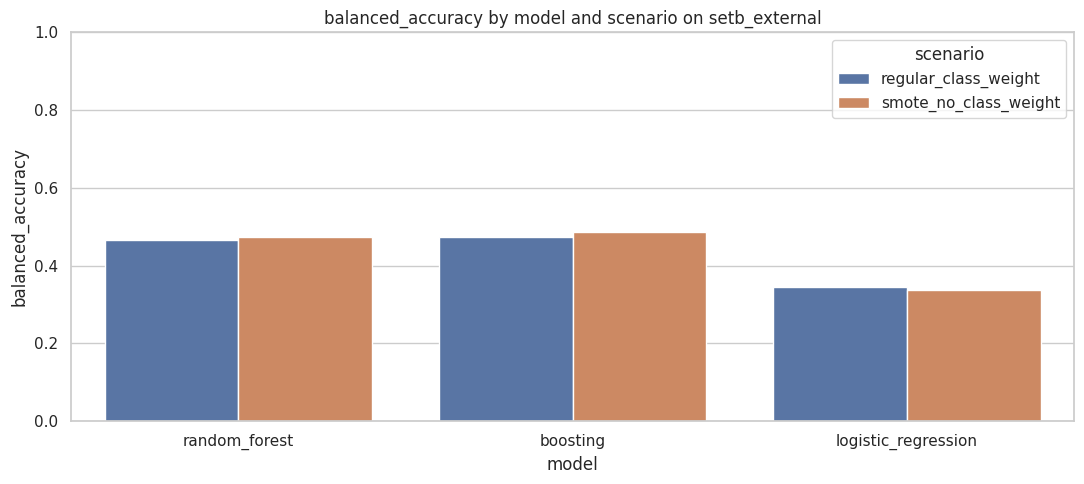

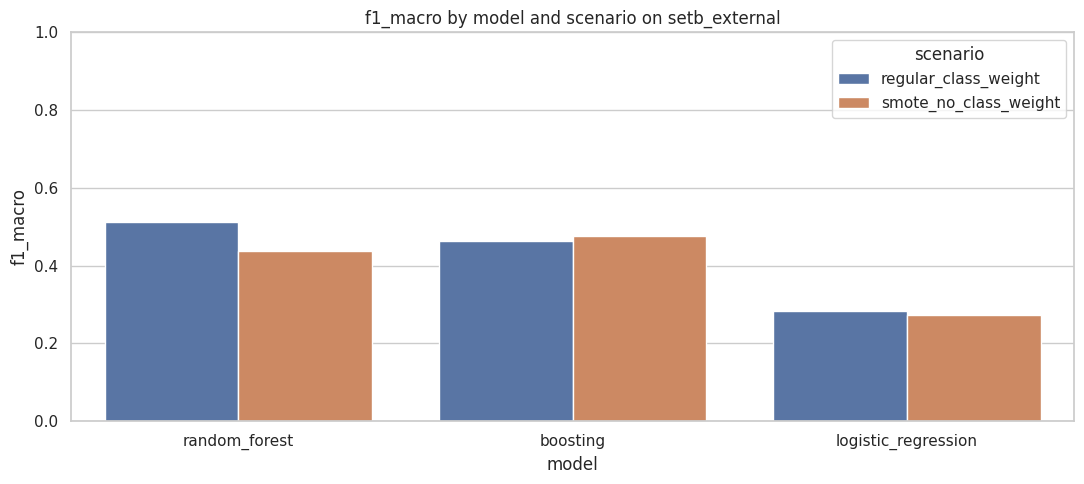

SMOTE delta (smote - regular):


,model,dataset,delta_accuracy,delta_balanced_accuracy,delta_f1_macro
0,logistic_regression,seta_test,-0.003079,0.012890,0.000551
1,logistic_regression,setb_external,-0.028485,-0.005698,-0.010564
2,random_forest,seta_test,-0.003599,0.019952,-0.021190
3,random_forest,setb_external,-0.014123,0.008834,-0.074970
4,boosting,seta_test,0.006641,-0.017609,0.010961
5,boosting,setb_external,0.012115,0.013533,0.011504


In [14]:
summary_pivot = results_df.pivot_table(

    index=["model", "scenario"],

    columns="dataset",

    values=["accuracy", "balanced_accuracy", "f1_macro"],

    aggfunc="mean",

)

display(summary_pivot)



# Plot metrics separately for each evaluation dataset to avoid averaging SetA and SetB together.

for ds in ["seta_test", "setb_external"]:

    subset = results_df[results_df["dataset"] == ds].copy()

    for metric in ["accuracy", "balanced_accuracy", "f1_macro"]:

        plt.figure(figsize=(11, 5))

        ax = sns.barplot(

            data=subset,

            x="model",

            y=metric,

            hue="scenario",

            errorbar=None,

        )

        ax.set_title(f"{metric} by model and scenario on {ds}")

        ax.set_ylim(0, 1)

        plt.tight_layout()

        plt.show()



delta_rows = []

for model_name in MODEL_NAMES:

    for ds in ["seta_test", "setb_external"]:

        reg = results_df[(results_df["model"] == model_name) & (results_df["scenario"] == "regular_class_weight") & (results_df["dataset"] == ds)]

        smo = results_df[(results_df["model"] == model_name) & (results_df["scenario"] == "smote_no_class_weight") & (results_df["dataset"] == ds)]



        if len(reg) == 1 and len(smo) == 1:

            delta_rows.append({

                "model": model_name,

                "dataset": ds,

                "delta_accuracy": float(smo.iloc[0]["accuracy"] - reg.iloc[0]["accuracy"]),

                "delta_balanced_accuracy": float(smo.iloc[0]["balanced_accuracy"] - reg.iloc[0]["balanced_accuracy"]),

                "delta_f1_macro": float(smo.iloc[0]["f1_macro"] - reg.iloc[0]["f1_macro"]),

            })



delta_df = pd.DataFrame(delta_rows)

print("SMOTE delta (smote - regular):")

display(delta_df)

Best on SetA test:


,model,scenario,dataset,accuracy,balanced_accuracy,f1_macro,fit_time_sec,predict_time_sec
0,boosting,smote_no_class_weight,seta_test,0.961675,0.870865,0.847417,3.144922,0.570133


Best on SetB external:


,model,scenario,dataset,accuracy,balanced_accuracy,f1_macro,fit_time_sec,predict_time_sec
6,random_forest,regular_class_weight,setb_external,0.938115,0.464864,0.513302,2.591633,0.258179


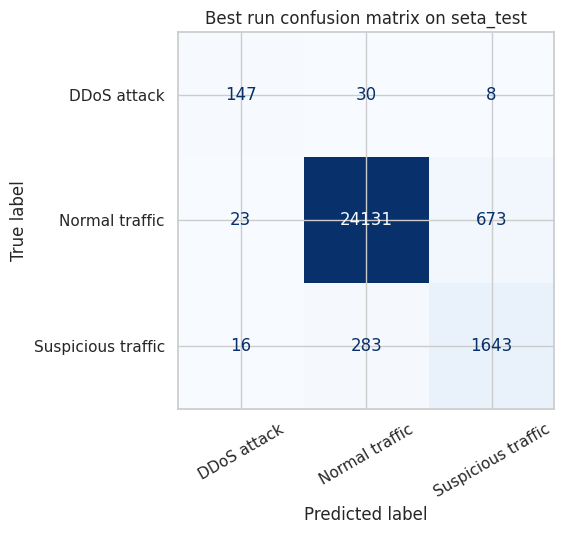

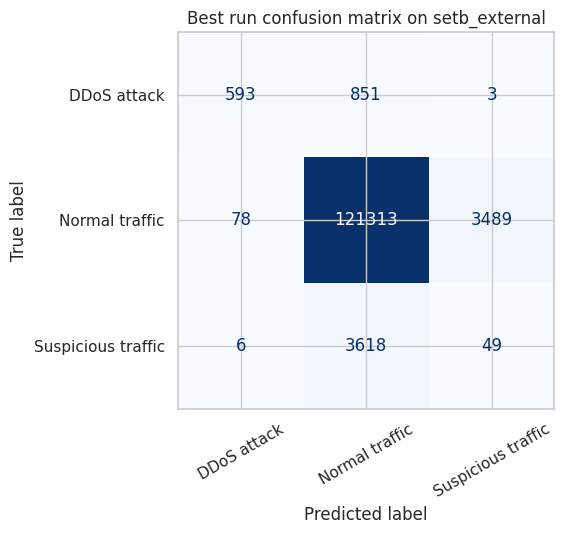

In [12]:
def best_run_for_dataset(results: pd.DataFrame, dataset_name: str):
    subset = results[results["dataset"] == dataset_name].copy()
    subset = subset.sort_values(["f1_macro", "balanced_accuracy", "accuracy"], ascending=False)
    return subset.iloc[0]

best_seta = best_run_for_dataset(results_df, "seta_test")
best_setb = best_run_for_dataset(results_df, "setb_external")

print("Best on SetA test:")
display(best_seta.to_frame().T)
print("Best on SetB external:")
display(best_setb.to_frame().T)

for ds_name, y_true, best_row in [
    ("seta_test", y_test, best_seta),
    ("setb_external", y_setb, best_setb),
]:
    key = (best_row["model"], best_row["scenario"])
    y_pred = predictions[key][ds_name]

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        ax=ax,
        cmap="Blues",
        xticks_rotation=30,
        colorbar=False,
    )
    ax.set_title(f"Best run confusion matrix on {ds_name}")
    plt.tight_layout()
    plt.show()

In [13]:
results_path = OUT_DIR / "model_comparison_results.csv"
delta_path = OUT_DIR / "model_comparison_smote_delta.csv"
summary_path = OUT_DIR / "model_comparison_summary_pivot.csv"
config_path = OUT_DIR / "model_comparison_config.json"

results_df.to_csv(results_path, index=False)
delta_df.to_csv(delta_path, index=False)
summary_pivot.reset_index().to_csv(summary_path, index=False)

config_payload = {
    "target": TARGET_COL,
    "seta": SETA_NAME,
    "setb": SETB_NAME,
    "test_size": TEST_SIZE,
    "val_size": VAL_SIZE,
    "random_state": RANDOM_STATE,
    "models": MODEL_NAMES,
    "scenarios": SCENARIOS,
    "boosting_backend": BOOSTING_BACKEND,
    "encoded_feature_count": len(feature_names),
}
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config_payload, f, indent=2)

print("Saved artifacts:")
print(f"- {results_path}")
print(f"- {delta_path}")
print(f"- {summary_path}")
print(f"- {config_path}")

Saved artifacts:
- ddos-detection/model_comparison/model_comparison_results.csv
- ddos-detection/model_comparison/model_comparison_smote_delta.csv
- ddos-detection/model_comparison/model_comparison_summary_pivot.csv
- ddos-detection/model_comparison/model_comparison_config.json


## Notes

- A benchmark fairness miatt ugyanazt a feature engineering es encoding logikat kapja minden modell.
- SMOTE csak a SetA train reszen fut (nincs adatfolyas val/test/SetB fele).
- SetB kizarolag external generalization meresre van hasznalva.
- Ha xgboost/lightgbm nincs telepitve, automatikus fallback a HistGradientBoostingClassifier.